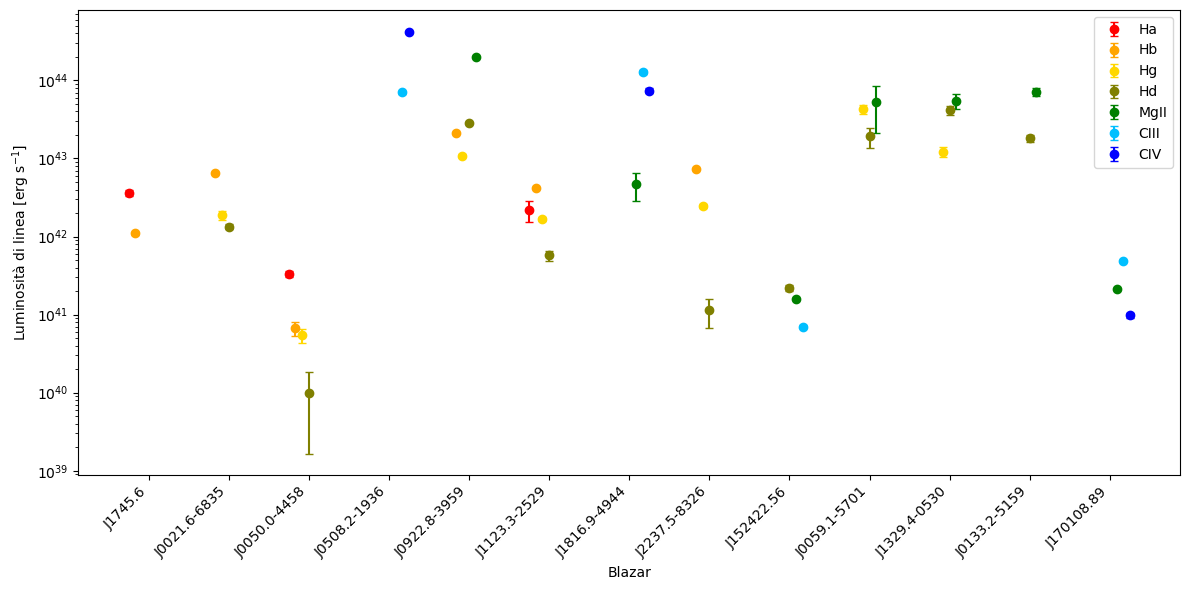

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === file di input ===
file_csv = "Tab_completa_revisione.csv"   # metti qui il path corretto se serve

# === mappa colori richiesta ===
color_map_linea = {
    "Ha": "red",
    "Hb": "orange",
    "Hg": "gold",
    "Hd": "olive",
    "MgII": "green",
    "CIII": "deepskyblue",
    "CIV": "blue"
}

# === lettura dati ===
df = pd.read_csv(file_csv)

# usa la colonna 'label' come nome del blazar
blazar_col = "label"

# fattore di scala: i valori nel file sono divisi per 1e42
scale = 1e42

# ordina le linee in un ordine comodo
linee_presenti = [linea for linea in color_map_linea
                  if f"{linea}_norm" in df.columns and f"{linea}_norm_unc" in df.columns]

# posizioni sull'asse x
x = np.arange(len(df))

# figura
plt.figure(figsize=(12, 6))

# piccolo offset per non sovrapporre completamente i punti delle varie linee
offsets = np.linspace(-0.25, 0.25, len(linee_presenti))

for off, linea in zip(offsets, linee_presenti):
    y = df[f"{linea}_norm"].to_numpy(dtype=float) * scale
    yerr = df[f"{linea}_norm_unc"].to_numpy(dtype=float) * scale

    # ignora NaN e valori non positivi/nulli
    mask = np.isfinite(y) & np.isfinite(yerr) & (y > 0)

    plt.errorbar(
        x[mask] + off,
        y[mask],
        yerr=yerr[mask],
        fmt='o',
        capsize=3,
        linestyle='none',
        color=color_map_linea[linea],
        label=linea,
    )

plt.xticks(x, df[blazar_col], rotation=45, ha='right')
plt.yscale("log")
plt.ylabel(r"Luminosità di linea [erg s$^{-1}$]")
plt.xlabel("Blazar")
plt.legend()
plt.tight_layout()
plt.show()